## Assignment: Image recognition
- Alumno 1:
- Alumno 2:
- Alumno 3:

The goals of the assignment are:
* Develop proficiency in using Tensorflow/Keras for training Neural Nets (NNs).
* Put into practice the acquired knowledge to optimize the parameters and architecture of a feedforward Neural Net (ffNN), in the context of an image recognition problem.
* Put into practice NNs specially conceived for analysing images. Design and optimize the parameters of a Convolutional Neural Net (CNN) to deal with previous task.
* Train popular architectures from scratch (e.g., GoogLeNet, VGG, ResNet, ...), and compare the results with the ones provided by their pre-trained versions using transfer learning.

Follow the link below to download the classification data set  “xview_recognition”: [https://drive.upm.es/s/2DDPE2zHw5dbM3G](https://drive.upm.es/s/2DDPE2zHw5dbM3G)

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import requests
import zipfile

url = 'https://drive.upm.es/s/2DDPE2zHw5dbM3G/download'
zip_name = 'dataset.zip'

r = requests.get(url, stream=True)
with open(zip_name, 'wb') as f:
    for chunk in r.iter_content(chunk_size=1024):
        f.write(chunk)

if os.path.getsize(zip_name) < 10000:
    print(f"ERREUR : Le fichier {zip_name} est trop petit. Le lien est invalide ou nécessite une connexion.")
else:
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall(".")

    target_file = 'xview_ann_train.json'
    found_path = None

    for root, dirs, files in os.walk("."):
        if target_file in files:
            found_path = os.path.join(root, target_file)
            break

    if found_path:
        print(f"SUCCÈS : Fichier trouvé à : {found_path}")

        import json
        json_file = found_path

        with open(json_file) as ifs:
            json_data = json.load(ifs)
        print("Base de données chargée avec succès !")

    else:
        print(f"ERREUR : {target_file} reste introuvable après extraction.")

SUCCÈS : Fichier trouvé à : ./xview_recognition/xview_ann_train.json
Base de données chargée avec succès !


In [2]:
import tensorflow as tf

# Vérifie la présence de processeurs graphiques
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Configuration pour ne pas allouer toute la mémoire d'un coup
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU activé : {len(gpus)} processeur(s) détecté(s)")
    except RuntimeError as e:
        print(e)
else:
    print("GPU non détecté. Activez l'accélérateur dans les réglages du notebook.")

2026-03-03 07:08:59.760460: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772521739.944563      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772521739.999148      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772521740.442460      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772521740.442494      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772521740.442497      25 computation_placer.cc:177] computation placer alr

GPU activé : 1 processeur(s) détecté(s)


In [3]:
import uuid
import numpy as np

class GenericObject:
    """
    Generic object data.
    """
    def __init__(self):
        self.id = uuid.uuid4()
        self.bb = (-1, -1, -1, -1)
        self.category= -1
        self.score = -1

class GenericImage:
    """
    Generic image data.
    """
    def __init__(self, filename):
        self.filename = filename
        self.tile = np.array([-1, -1, -1, -1])  # (pt_x, pt_y, pt_x+width, pt_y+height)
        self.objects = list([])

    def add_object(self, obj: GenericObject):
        self.objects.append(obj)

In [4]:
categories = {0: 'Cargo plane', 1: 'Small car', 2: 'Bus', 3: 'Truck', 4: 'Motorboat', 5: 'Fishing vessel', 6: 'Dump truck', 7: 'Excavator', 8: 'Building', 9: 'Helipad', 10: 'Storage tank', 11: 'Shipping container', 12: 'Pylon'}

In [5]:
!pip install rasterio

In [6]:
import warnings
import rasterio
import numpy as np

def load_geoimage(filename):
    warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)
    src_raster = rasterio.open('./xview_recognition/'+filename, 'r')
    # RasterIO to OpenCV (see inconsistencies between libjpeg and libjpeg-turbo)
    input_type = src_raster.profile['dtype']
    input_channels = src_raster.count
    img = np.zeros((src_raster.height, src_raster.width, src_raster.count), dtype=input_type)
    for band in range(input_channels):
        img[:, :, band] = src_raster.read(band+1)
    return img

#### Training
Design and train a ffNN to deal with the “xview_recognition” classification task.

In [7]:
import json

# Load database
json_file = './xview_recognition/xview_ann_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

In [8]:
import numpy as np

counts = dict.fromkeys(categories.values(), 0)
anns = []
for json_img, json_ann in zip(json_data['images'].values(), json_data['annotations'].values()):
    image = GenericImage(json_img['filename'])
    image.tile = np.array([0, 0, json_img['width'], json_img['height']])
    obj = GenericObject()
    obj.bb = (int(json_ann['bbox'][0]), int(json_ann['bbox'][1]), int(json_ann['bbox'][2]), int(json_ann['bbox'][3]))
    obj.category = json_ann['category_id']
    # Resampling strategy to reduce training time
    counts[obj.category] += 1
    image.add_object(obj)
    anns.append(image)
print(counts)
labels = [img.objects[0].category for img in anns]

{'Cargo plane': 635, 'Small car': 3324, 'Bus': 1768, 'Truck': 2210, 'Motorboat': 1069, 'Fishing vessel': 706, 'Dump truck': 1236, 'Excavator': 789, 'Building': 3594, 'Helipad': 111, 'Storage tank': 1469, 'Shipping container': 1523, 'Pylon': 312}


In [9]:
from sklearn.model_selection import train_test_split

anns_train, anns_valid = train_test_split(anns, test_size=0.15, random_state=42, shuffle=True, stratify=labels)
print('Number of training images: ' + str(len(anns_train)))
print('Number of validation images: ' + str(len(anns_valid)))

Number of training images: 15934
Number of validation images: 2812


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, RandomFlip, RandomRotation
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.losses import CategoricalFocalCrossentropy
from tensorflow.keras.optimizers import Nadam

num_classes = len(categories)
input_shape = (128, 128, 3)

def compile_model(model):
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=0.0005,
        decay_steps=100 * (len(anns_train) // 128)
    )
    model.compile(
        optimizer=Nadam(learning_rate=lr_schedule, weight_decay=1e-4),
        loss=CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0),
        metrics=['accuracy']
    )
    return model

def create_xview_cnn(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    
    x = RandomFlip("horizontal_and_vertical")(inputs)
    x = RandomRotation(0.5)(x)
    
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((2, 2))(x)
    
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return compile_model(Model(inputs, outputs, name="xView_CNN"))

def create_satellite_resnet(input_shape, num_classes):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Extraction à un niveau intermédiaire pour éviter une trop forte spécialisation ImageNet
    early_output = base_model.get_layer('conv4_block6_out').output
    
    x = GlobalAveragePooling2D()(early_output)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs, name="ResNet50_Transfer")
    
    # Gel partiel pour le fine-tuning
    for layer in model.layers[:-30]:
        layer.trainable = False
    for layer in model.layers[-30:]:
        layer.trainable = True
        
    return compile_model(model)

models = [
    create_xview_cnn(input_shape, num_classes), 
    create_satellite_resnet(input_shape, num_classes)
]

I0000 00:00:1772521770.263834      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
#from tensorflow.keras.optimizers import Adam
#
## Learning rate is changed to 0.001
#opt = Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
#model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [12]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
#reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1)
early_stop = EarlyStopping('val_accuracy', patience=10, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, early_stop, terminate]

In [13]:
import numpy as np
import tensorflow as tf

def generator_images(objs, batch_size, do_shuffle=False):
    while True:
        working = list(objs)
        if do_shuffle:
            np.random.shuffle(working)
        groups = [working[i:i+batch_size] for i in range(0, len(working), batch_size)]
        
        for group in groups:
            images, labels = [], []
            for (filename, obj) in group:
                img = load_geoimage(filename)
                img = img.astype(np.float32)
                if img.ndim == 4:
                    img = img.squeeze(0)
                img_max = img.max()
                if img_max > 1.0:
                    img = img / 255.0 if img_max <= 255.0 else img / 65535.0

                # Forcer 3 canaux
                if img.shape[2] == 1:
                    img = np.repeat(img, 3, axis=2)
                elif img.shape[2] == 4:
                    img = img[:, :, :3]

                # Crop avec marge 15%
                x1, y1, x2, y2 = int(obj.bb[0]), int(obj.bb[1]), int(obj.bb[2]), int(obj.bb[3])
                h_img, w_img = img.shape[0], img.shape[1]
                bw, bh = max(1, x2 - x1), max(1, y2 - y1)
                pad_x, pad_y = max(4, int(bw * 0.15)), max(4, int(bh * 0.15))
                
                x1c, y1c = max(0, x1 - pad_x), max(0, y1 - pad_y)
                x2c, y2c = min(w_img, x2 + pad_x), min(h_img, y2 + pad_y)
                crop = img[y1c:y2c, x1c:x2c, :]
                if crop.shape[0] == 0 or crop.shape[1] == 0:
                    crop = img

                img_resized = tf.image.resize(tf.convert_to_tensor(crop), [128, 128], method='lanczos3')
                images.append(img_resized.numpy())

                cat_idx = list(categories.values()).index(obj.category)
                one_hot = tf.keras.utils.to_categorical(cat_idx, num_classes=len(categories))
                labels.append(one_hot)

            yield np.array(images, dtype=np.float32), np.array(labels, dtype=np.float32)

In [14]:
import math
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

batch_size = 128
objs_train = [(ann.filename, obj) for ann in anns_train for obj in ann.objects]
objs_valid = [(ann.filename, obj) for ann in anns_valid for obj in ann.objects]

# Variables indispensables pour l'entraînement
steps_per_epoch = math.ceil(len(objs_train) / batch_size)
valid_steps = math.ceil(len(objs_valid) / batch_size)

print('Calcul des poids de classes...')
y_train_indices = [list(categories.values()).index(obj.category) for _, obj in objs_train]
weights = compute_class_weight('balanced', classes=np.unique(y_train_indices), y=y_train_indices)

# On uniformise le nom de variable attendu par model.fit()
class_weight_dict = dict(enumerate(weights))

# (Optionnel) Ajustements manuels si nécessaire
class_weight_dict[3] *= 1.5 
class_weight_dict[9] *= 1.5

Calcul des poids de classes...


In [15]:
import numpy as np
import tensorflow as tf

print("Début de l'entraînement")
max_epochs = 150
histories = {}

# Utilisation de tf.data.Dataset (contourne l'erreur liée à class_weight_dict)
train_dataset = tf.data.Dataset.from_generator(
    lambda: generator_images(objs_train, batch_size=batch_size, do_shuffle=True),
    output_signature=(
        tf.TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, len(categories)), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_generator(
    lambda: generator_images(objs_valid, batch_size=batch_size, do_shuffle=False),
    output_signature=(
        tf.TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, len(categories)), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

for m in models:
    print(f"\n--- Entraînement du modèle : {m.name} ---")
    
    current_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(f'{m.name}_best.keras', monitor='val_accuracy', save_best_only=True, mode='max'),
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
        tf.keras.callbacks.TerminateOnNaN()
    ]
    
    h = m.fit(
        train_dataset,
        steps_per_epoch=steps_per_epoch,
        validation_data=valid_dataset,
        validation_steps=valid_steps,
        epochs=max_epochs,
        callbacks=current_callbacks,
        class_weight=class_weight_dict,
        verbose=1
    )
    histories[m.name] = h
    
    best_idx = int(np.argmax(h.history['val_accuracy']))
    best_value = np.max(h.history['val_accuracy'])
    print(f'Meilleur résultat pour {m.name} : époque {best_idx+1} - val_accuracy {best_value:.4f}')

Début de l'entraînement

--- Entraînement du modèle : xView_CNN ---
Epoch 1/150


I0000 00:00:1772521778.345673      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


125/125 ━━━━━━━━━━━━━━━━━━━━ 131s 988ms/step - accuracy: 0.1487 - loss: 0.5535 - val_accuracy: 0.2927 - val_loss: 0.4275
Epoch 2/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 116s 937ms/step - accuracy: 0.2431 - loss: 0.4412 - val_accuracy: 0.2866 - val_loss: 0.3885
Epoch 3/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 121s 972ms/step - accuracy: 0.2827 - loss: 0.4089 - val_accuracy: 0.3432 - val_loss: 0.3733
Epoch 4/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 114s 916ms/step - accuracy: 0.3221 - loss: 0.3790 - val_accuracy: 0.3734 - val_loss: 0.3229
Epoch 5/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 111s 897ms/step - accuracy: 0.3227 - loss: 0.3784 - val_accuracy: 0.4132 - val_loss: 0.3019
Epoch 6/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 115s 923ms/step - accuracy: 0.3579 - loss: 0.3416 - val_accuracy: 0.4285 - val_loss: 0.3055
Epoch 7/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 113s 907ms/step - accuracy: 0.3797 - loss: 0.3208 - val_accuracy: 0.4331 - val_loss: 0.2926
Epoch 8/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 111s 895ms/step - accuracy: 0.3803 - los

I0000 00:00:1772527909.480455      70 service.cc:152] XLA service 0x1fa65d30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772527909.480534      70 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
2026-03-03 08:51:53.948086: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:51:54.167126: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:51:54.552390: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
20

  2/125 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.0586 - loss: 0.6806  

...

124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.1075 - loss: 0.6187

2026-03-03 08:53:36.937168: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:53:37.296454: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:53:37.933746: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.1077 - loss: 0.6183

2026-03-03 08:54:04.182924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


125/125 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.1079 - loss: 0.6180 - val_accuracy: 0.1881 - val_loss: 1.2278
Epoch 2/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 117s 941ms/step - accuracy: 0.1890 - loss: 0.5010 - val_accuracy: 0.1924 - val_loss: 2.2398
Epoch 3/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 113s 913ms/step - accuracy: 0.2320 - loss: 0.4407 - val_accuracy: 0.1799 - val_loss: 3.2166
Epoch 4/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 112s 902ms/step - accuracy: 0.2712 - loss: 0.3878 - val_accuracy: 0.0765 - val_loss: 2.9979
Epoch 5/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 110s 889ms/step - accuracy: 0.3013 - loss: 0.3654 - val_accuracy: 0.0914 - val_loss: 1.2226
Epoch 6/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 111s 891ms/step - accuracy: 0.3152 - loss: 0.3560 - val_accuracy: 0.0839 - val_loss: 3.2320
Epoch 7/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 114s 916ms/step - accuracy: 0.3469 - loss: 0.3309 - val_accuracy: 0.2084 - val_loss: 0.7707
Epoch 8/150
125/125 ━━━━━━━━━━━━━━━━━━━━ 112s 900ms/step - accuracy: 0.3548 - loss: 

#### Validation
Compute validation metrics.

In [16]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.colormaps['Blues'])
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show()

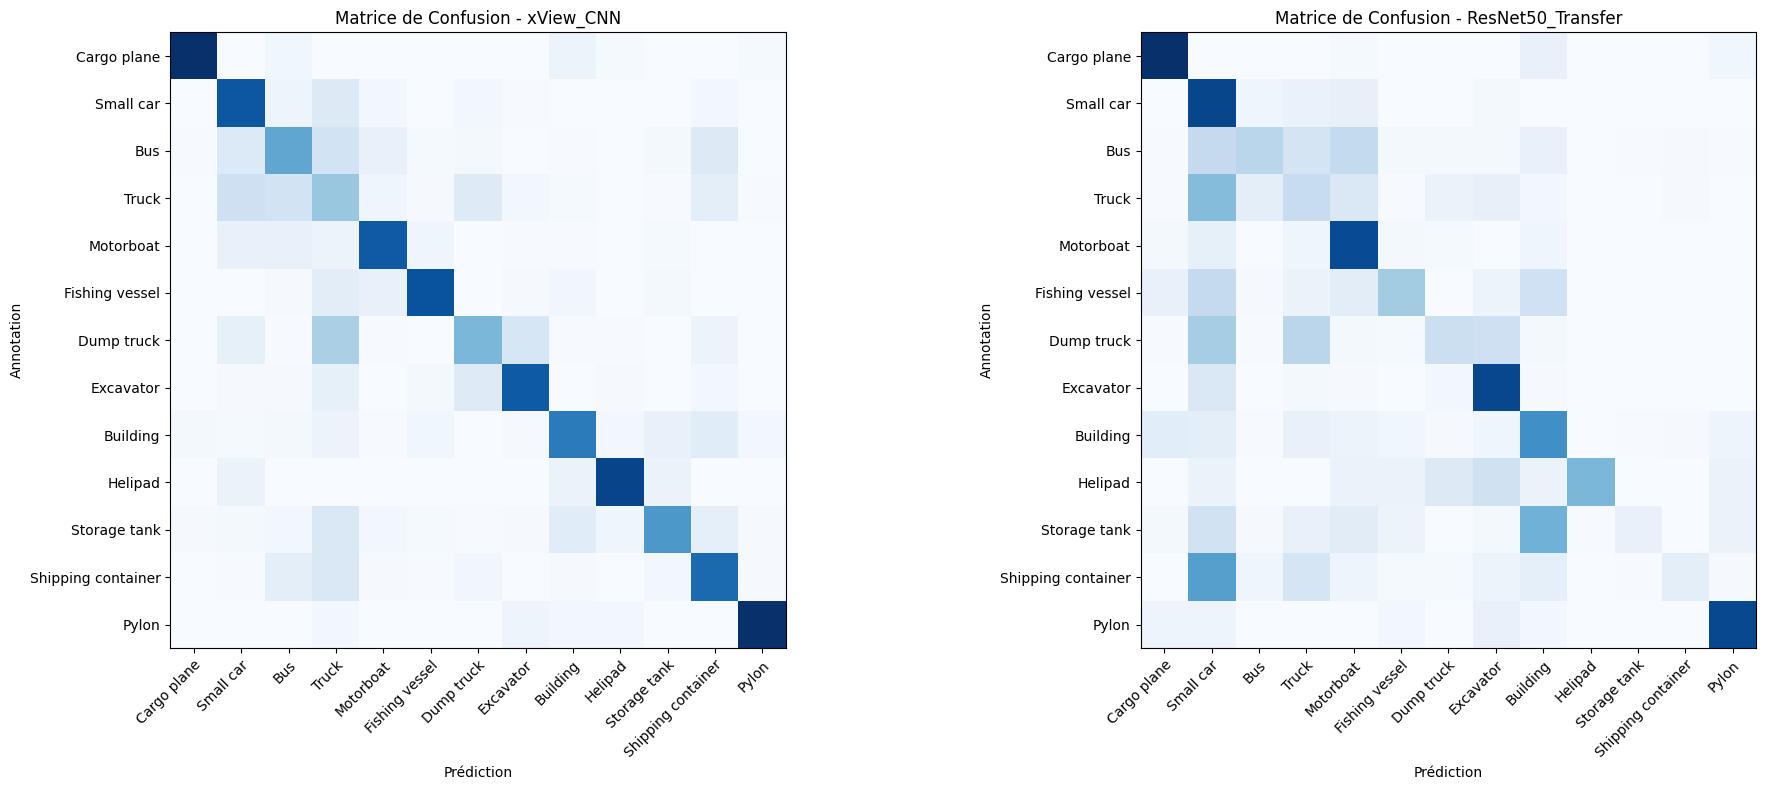

In [17]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

IMG_SIZE = 128

all_images, temp_true_labels = [], []

for ann in anns_valid:
    image_raw = load_geoimage(ann.filename)
    img = image_raw.astype(np.float32)
    if img.ndim == 4: img = img.squeeze(0)
    img_max = img.max()
    if img_max > 1.0: img = img / 255.0 if img_max <= 255.0 else img / 65535.0

    # Forcer 3 canaux
    if img.shape[2] == 1:
        img = np.repeat(img, 3, axis=2)
    elif img.shape[2] == 4:
        img = img[:, :, :3]

    for obj_pred in ann.objects:
        x1, y1, x2, y2 = int(obj_pred.bb[0]), int(obj_pred.bb[1]), int(obj_pred.bb[2]), int(obj_pred.bb[3])
        h_img, w_img = img.shape[0], img.shape[1]
        bw, bh = max(1, x2 - x1), max(1, y2 - y1)
        pad_x, pad_y = max(4, int(bw * 0.15)), max(4, int(bh * 0.15))
        
        x1c, y1c = max(0, x1 - pad_x), max(0, y1 - pad_y)
        x2c, y2c = min(w_img, x2 + pad_x), min(h_img, y2 + pad_y)
        crop = img[y1c:y2c, x1c:x2c, :]
        if crop.shape[0] == 0 or crop.shape[1] == 0: crop = img

        img_resized = tf.image.resize(tf.convert_to_tensor(crop), [IMG_SIZE, IMG_SIZE], method='lanczos3')
        all_images.append(img_resized.numpy())
        temp_true_labels.append(obj_pred.category)

X_valid = np.array(all_images)
category_names = list(categories.values())

def plot_cm(ax, cm, title):
    cm_norm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
    ax.set_title(title)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), 
           xticklabels=category_names, yticklabels=category_names, 
           ylabel='Annotation', xlabel='Prédiction')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for idx, m in enumerate(models):
    m.load_weights(f'{m.name}_best.keras')
    preds = m.predict(X_valid, batch_size=128, verbose=0)
    y_pred = [category_names[np.argmax(p)] for p in preds]
    
    cm = confusion_matrix(temp_true_labels, y_pred, labels=category_names)
    plot_cm(axes[idx], cm, f"Matrice de Confusion - {m.name}")

plt.tight_layout()
plt.show()

In [18]:
#from sklearn.metrics import confusion_matrix
#
#cm = confusion_matrix(y_true, y_pred)
#draw_confusion_matrix(cm, categories)

In [19]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 46.550%
Mean Recall: 48.073%
Mean Precision: 53.097%
> Cargo plane: Recall: 89.474% Precision: 54.140% Specificity: 97.350% Dice: 67.460%
> Small car: Recall: 81.563% Precision: 44.824% Specificity: 78.340% Dice: 57.854%
> Bus: Recall: 25.660% Precision: 51.908% Specificity: 97.527% Dice: 34.343%
> Truck: Recall: 21.386% Precision: 24.653% Specificity: 91.250% Dice: 22.903%
> Motorboat: Recall: 80.000% Precision: 37.537% Specificity: 91.968% Dice: 51.098%
> Fishing vessel: Recall: 32.075% Precision: 43.038% Specificity: 98.337% Dice: 36.757%
> Dump truck: Recall: 19.459% Precision: 48.000% Specificity: 98.515% Dice: 27.692%
> Excavator: Recall: 81.356% Precision: 45.283% Specificity: 95.694% Dice: 58.182%
> Building: Recall: 56.401% Precision: 63.071% Specificity: 92.169% Dice: 59.549%
> Helipad: Recall: 41.176% Precision: 87.500% Specificity: 99.964% Dice: 56.000%
> Storage tank: Recall: 6.818% Precision: 75.000% Specificity: 99.807% Dice: 12.500%
> Shipping container: 

#### Testing
Try to improve the results provided in the competition.

In [20]:
import os
import numpy as np

anns = []
root_dir = './xview_recognition/'
test_dir = os.path.join(root_dir, 'xview_test')
for (dirpath, dirnames, filenames) in os.walk(test_dir):
    for filename in filenames:
        rel_dir = os.path.relpath(dirpath, root_dir)
        clean_filename = os.path.join(rel_dir, filename)
        image = GenericImage(clean_filename)
        image.tile = np.array([0, 0, 224, 224])
        obj = GenericObject()
        obj.bb = (0, 0, 224, 224)
        obj.category = os.path.basename(dirpath)
        image.add_object(obj)
        anns.append(image)
print('Number of testing images: ' + str(len(anns)))

Number of testing images: 2365


In [21]:
import json
import numpy as np
import tensorflow as tf

best_model = models[1]
best_model.load_weights(f'{best_model.name}_best.keras')

predictions_data = {"images": {}, "annotations": {}}
all_test_images = []
metadata = []
ann_id = 0

for idx, ann in enumerate(anns):
    predictions_data["images"][idx] = {
        "image_id": ann.filename.split('/')[-1],
        "filename": ann.filename,
        "width": int(ann.tile[2]),
        "height": int(ann.tile[3])
    }

    image_raw = load_geoimage(ann.filename)
    img = image_raw.astype(np.float32)
    if img.ndim == 4: img = img.squeeze(0)
    img_max = img.max()
    if img_max > 1.0: img = img / 255.0 if img_max <= 255.0 else img / 65535.0

    # Forcer 3 canaux
    if img.shape[2] == 1:
        img = np.repeat(img, 3, axis=2)
    elif img.shape[2] == 4:
        img = img[:, :, :3]

    img_resized = tf.image.resize(tf.convert_to_tensor(img), [128, 128], method='lanczos3')
    img_final = img_resized.numpy()

    for obj_pred in ann.objects:
        all_test_images.append(img_final)
        metadata.append({
            "image_id": ann.filename.split('/')[-1],
            "bbox": [int(x) for x in obj_pred.bb]
        })

if all_test_images:
    X_test = np.array(all_test_images)
    all_preds = best_model.predict(X_test, batch_size=128, verbose=1)
    
    category_names = list(categories.values())
    for i, pred in enumerate(all_preds):
        predictions_data["annotations"][ann_id] = {
            "image_id": metadata[i]["image_id"],
            "category_id": category_names[np.argmax(pred)],
            "bbox": metadata[i]["bbox"]
        }
        ann_id += 1

with open('prediction.json', 'w') as f:
    json.dump(predictions_data, f)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step


In [22]:
#for i, model in enumerate(models):
#    model.load_weights(f'model_{i}.keras')

In [23]:
import json
with open('prediction.json', 'w') as f:
    json.dump(predictions_data, f)